# Silver LMS EDA

A simple check of the silver loan table and label stability by month on book (MOB).

In [4]:
import matplotlib.pyplot as plt
import pyspark
from pyspark.sql import functions as F
from pyspark.sql.window import Window

spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

In [5]:
silver_lms = (
    spark.read
    .option("recursiveFileLookup", "true")
    .parquet("datamart/silver/loan_daily/")
)

silver_lms.select(
    F.count("*").alias("row_count"),
    F.countDistinct("loan_id").alias("loan_count"),
    F.min("mob").alias("minimum_mob"),
    F.max("mob").alias("maximum_mob"),
).show()

duplicate_keys = (
    silver_lms.groupBy("loan_id", "mob")
    .count()
    .filter(F.col("count") > 1)
    .count()
)
print("Duplicate loan/MOB keys:", duplicate_keys)
silver_lms.orderBy("loan_id", "mob").show(5)

+---------+----------+-----------+-----------+
|row_count|loan_count|minimum_mob|maximum_mob|
+---------+----------+-----------+-----------+
|   137500|     12500|          0|         10|
+---------+----------+-----------+-----------+

Duplicate loan/MOB keys: 0
+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+
|             loan_id|Customer_ID|loan_start_date|tenure|installment_num|loan_amt|due_amt|paid_amt|overdue_amt|balance|snapshot_date|mob|installments_missed|first_missed_date|dpd|
+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+
|CUS_0x1000_2023_0...| CUS_0x1000|     2023-05-01|    10|              0| 10000.0|    0.0|     0.0|        0.0|10000.0|   2023-05-01|  0|                  0|             NULL|  0|
|CUS_0x1000_2023_

In [6]:
dpd_threshold = 30

loan_window = (
    Window.partitionBy("loan_id")
    .orderBy("mob")
    .rowsBetween(Window.unboundedPreceding, Window.currentRow)
)

loan_performance = (
    silver_lms
    .filter(F.col("mob").between(1, 10))
    .withColumn(
        "bad_at_mob",
        F.when(F.col("dpd") >= dpd_threshold, 1).otherwise(0),
    )
    .withColumn(
        "ever_bad_by_mob",
        F.max("bad_at_mob").over(loan_window),
    )
)

mob_summary = (
    loan_performance.groupBy("mob")
    .agg(
        F.countDistinct("loan_id").alias("loan_count"),
        F.avg("bad_at_mob").alias("bad_rate_at_mob"),
        F.avg("ever_bad_by_mob").alias("cumulative_bad_rate"),
    )
    .orderBy("mob")
)

mob_summary.show(10, truncate=False)

+---+----------+---------------+-------------------+
|mob|loan_count|bad_rate_at_mob|cumulative_bad_rate|
+---+----------+---------------+-------------------+
|1  |12500     |0.05104        |0.05104            |
|2  |12500     |0.10072        |0.13136            |
|3  |12500     |0.16968        |0.22296            |
|4  |12500     |0.22696        |0.27416            |
|5  |12500     |0.28344        |0.28744            |
|6  |12500     |0.28816        |0.28816            |
|7  |12500     |0.28816        |0.28816            |
|8  |12500     |0.28816        |0.28816            |
|9  |12500     |0.28816        |0.28816            |
|10 |12500     |0.28816        |0.28816            |
+---+----------+---------------+-------------------+



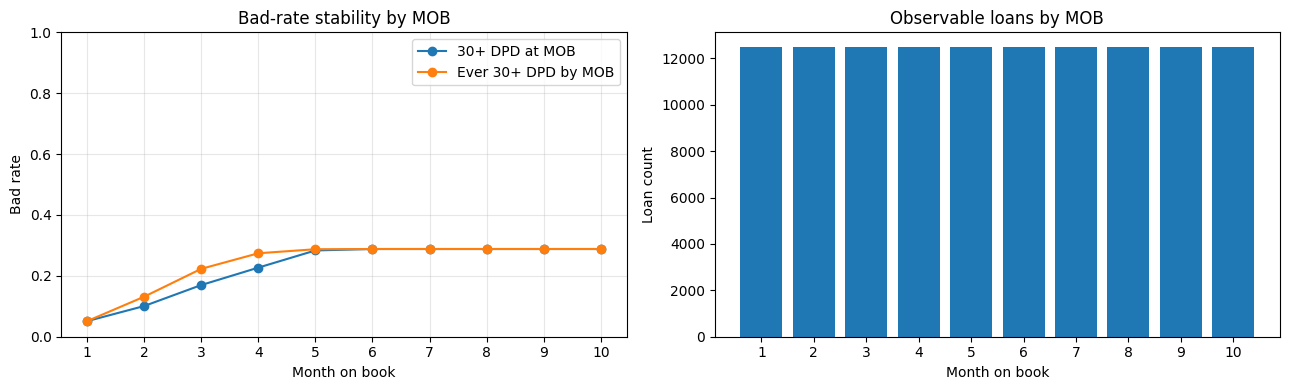

In [7]:
mob_pdf = mob_summary.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(mob_pdf["mob"], mob_pdf["bad_rate_at_mob"], marker="o", label="30+ DPD at MOB")
axes[0].plot(mob_pdf["mob"], mob_pdf["cumulative_bad_rate"], marker="o", label="Ever 30+ DPD by MOB")
axes[0].set_title("Bad-rate stability by MOB")
axes[0].set_xlabel("Month on book")
axes[0].set_ylabel("Bad rate")
axes[0].set_xticks(mob_pdf["mob"])
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].bar(mob_pdf["mob"], mob_pdf["loan_count"])
axes[1].set_title("Observable loans by MOB")
axes[1].set_xlabel("Month on book")
axes[1].set_ylabel("Loan count")
axes[1].set_xticks(mob_pdf["mob"])

plt.tight_layout()
plt.show()

The first line is delinquency at each specific MOB. The cumulative line is whether a loan has ever reached 30+ DPD by that MOB. The bar chart shows whether enough loans have matured at each horizon.